## Day 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import hashlib
import pandas as pd
import pandera.pandas as pa
from pandera import Column, DataFrameSchema, Check
import seaborn as sns
import random


In [2]:
random.seed(42)
np.random.seed(42)

In [3]:
df = pd.read_csv("telco-customer-churn-by-IBM.csv")
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No


In [4]:
df['OnlineBackup'].sample(4)

5407    Yes
2336     No
5063    Yes
1516     No
Name: OnlineBackup, dtype: object

In [5]:


with open("telco-customer-churn-by-IBM.csv", "rb") as f:
    file_hash = hashlib.md5(f.read()).hexdigest()

print(file_hash)

0f9de68e012bd3aed5fa7cdc9fc421af


In [6]:
df['Churn'].unique()


array(['No', 'Yes'], dtype=object)

# Schema checks with Pandera


In [7]:
# Convert TotalCharges to numeric (fix object type)
from pandera import DataFrameSchema

df['TotalCharges'] = (
    df['TotalCharges']
    .replace(" ", 0)   # blank → 0
    .astype(float)
)

# Convert Churn to binary numeric (0 = No, 1 = Yes)
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

schema = DataFrameSchema(
    {
        "customerID": Column(str, nullable=False),
        "gender": Column(str, nullable=False),
        "SeniorCitizen": Column(int, Check.in_range(0,1), nullable=False),
        "Partner": Column(str, nullable=False),
        "Dependents": Column(str, nullable=False),
        "tenure": Column(int, Check.ge(0), nullable=False),
        "PhoneService": Column(str, nullable=False),
        "MultipleLines": Column(str, nullable=False),
        "InternetService": Column(str, nullable=False),
        "OnlineSecurity": Column(str, nullable=False),
        "OnlineBackup": Column(str, nullable=False),
        "DeviceProtection": Column(str, nullable=False),
        "TechSupport": Column(str, nullable=False),
        "StreamingTV": Column(str, nullable=False),
        "StreamingMovies": Column(str, nullable=False),
        "Contract": Column(str, nullable=False),
        "PaperlessBilling": Column(str, nullable=False),
        "PaymentMethod": Column(str, nullable=False),
        "MonthlyCharges": Column(float, Check.ge(0), nullable=False),
        "TotalCharges": Column(float, Check.ge(0), nullable=False),
        "Churn": Column(int, Check.in_range(0,1), nullable=False)
    },

    checks=[
        # Tenure=0 → TotalCharges=0; Tenure>0 → TotalCharges>0
        Check(
            lambda df: (df["tenure"] == 0).equals(df["TotalCharges"] == 0),
            error="Tenure and TotalCharges relationship invalid."
        ),

        # TotalCharges should increase with tenure (rough check)
        Check(
            lambda df: df["TotalCharges"].corr(df["tenure"]) > 0.5,
            error="Correlation between tenure and charges unexpectedly low."
        )
    ]
)
validated_df = schema.validate(df)

c:\Users\Acer\Desktop\projects\week_2\churn_env\Lib\site-packages\pandera\_pandas_deprecated.py:149: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)


# Leakage Checklist

In [8]:
import pandas as pd

leakage_checklist = [
    {"Feature": "customerID", "Type": "ID", "Risk": "Low", "Notes": "Never use in model"},
    {"Feature": "TotalCharges", "Type": "Numeric", "Risk": "Low", "Notes": "Safe, only past charges"},
    {"Feature": "tenure", "Type": "Numeric", "Risk": "Low", "Notes": "Only past tenure included"},
    {"Feature": "MonthlyCharges", "Type": "Numeric", "Risk": "Low", "Notes": "Only current charges included"},
    {"Feature": "Contract", "Type": "Categorical", "Risk": "Low", "Notes": "Only info available at signup"},
    {"Feature": "OnlineSecurity", "Type": "Categorical", "Risk": "Low", "Notes": "Status at current month"},
    {"Feature": "TechSupport", "Type": "Categorical", "Risk": "Low", "Notes": "Status at current month"},
    {"Feature": "PaymentMethod", "Type": "Categorical", "Risk": "Low", "Notes": "Check if known at prediction time"},
    {"Feature": "PaperlessBilling", "Type": "Categorical", "Risk": "Low", "Notes": "Safe"},
    {"Feature": "Dependents", "Type": "Categorical", "Risk": "Low", "Notes": "Safe"},
    {"Feature": "Partner", "Type": "Categorical", "Risk": "Low", "Notes": "Safe"},
    {"Feature": "StreamingTV", "Type": "Categorical", "Risk": "Low", "Notes": "Safe"},
    {"Feature": "StreamingMovies", "Type": "Categorical", "Risk": "Low", "Notes": "Safe"},
    {"Feature": "MultipleLines", "Type": "Categorical", "Risk": "Low", "Notes": "Safe"},
    {"Feature": "DeviceProtection", "Type": "Categorical", "Risk": "Low", "Notes": "Safe"},
    {"Feature": "OnlineBackup", "Type": "Categorical", "Risk": "Low", "Notes": "Safe"},
    {"Feature": "Churn", "Type": "Target", "Risk": "High", "Notes": "Do not include as input"},
     
]

# Convert to DataFrame for tabular display
df_leakage = pd.DataFrame(leakage_checklist)

# Display
print(df_leakage.to_markdown(index=False))


| Feature          | Type        | Risk   | Notes                             |
|:-----------------|:------------|:-------|:----------------------------------|
| customerID       | ID          | Low    | Never use in model                |
| TotalCharges     | Numeric     | Low    | Safe, only past charges           |
| tenure           | Numeric     | Low    | Only past tenure included         |
| MonthlyCharges   | Numeric     | Low    | Only current charges included     |
| Contract         | Categorical | Low    | Only info available at signup     |
| OnlineSecurity   | Categorical | Low    | Status at current month           |
| TechSupport      | Categorical | Low    | Status at current month           |
| PaymentMethod    | Categorical | Low    | Check if known at prediction time |
| PaperlessBilling | Categorical | Low    | Safe                              |
| Dependents       | Categorical | Low    | Safe                              |
| Partner          | Categorical | Low  

In [9]:
df.shape

(7043, 21)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True)


Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

# Defining business costs

In [13]:
cost_fn = 1  # Cost of false negative
cost_fp = 5  # Cost of false positive

In [14]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,0.265370
std,0.368612,24.559481,30.090047,2266.794470,0.441561
min,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,0.000000
50%,0.000000,29.000000,70.350000,1394.550000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [15]:


# Categorical columns and unique counts
categorical_cols = df.select_dtypes(include='object').columns

print(df[categorical_cols].nunique())



customerID          7043
gender                 2
Partner                2
Dependents             2
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
dtype: int64


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Splitting into train-test making sure class distribution is balanced in train and test using Stratify

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop(['Churn','customerID','TotalCharges'], axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train/Test split done. Train shape:", X_train.shape, "Test shape:", X_test.shape)

# Check distribution
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))


Train/Test split done. Train shape: (5634, 18) Test shape: (1409, 18)
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


# Day2 

Baseline Metrics:
Accuracy: 0.7346
Confusion Matrix:
[[1035    0]
 [ 374    0]]


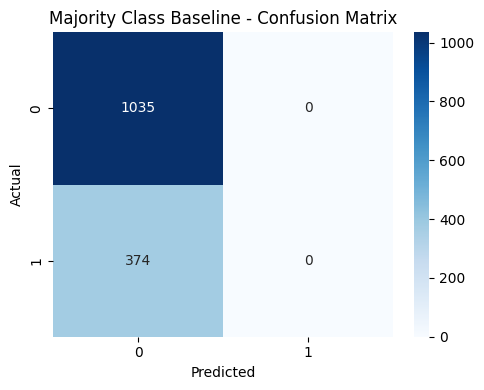

c:\Users\Acer\Desktop\projects\week_2\churn_env\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)


Majority class baseline logged successfully!
Run ID: 3be1169c1e934745bcdc087840e40ac6
Open MLflow UI in terminal: `mlflow ui`


In [18]:
import mlflow
import numpy as np
import pandas as pd
import json
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    precision_recall_curve, roc_curve, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Majority class baseline
# -----------------------------
majority_class = y_train.value_counts().idxmax()
y_pred_baseline = np.array([majority_class] * len(y_test))
y_prob_baseline = np.ones(len(y_test)) * (1 if majority_class == 1 else 0)

# -----------------------------
# Metrics
# -----------------------------
acc = accuracy_score(y_test, y_pred_baseline)
cm = confusion_matrix(y_test, y_pred_baseline)

print("Baseline Metrics:")
print(f"Accuracy: {acc:.4f}")
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Majority Class Baseline - Confusion Matrix")
plt.tight_layout()
plt.show()

# -----------------------------
# Log with MLflow
# -----------------------------
with mlflow.start_run(run_name="Majority Class Baseline") as run:

    # Log parameters
    mlflow.log_param("baseline_type", "majority_class")
    mlflow.log_param("majority_class", int(majority_class))
    mlflow.log_param("train_positive_prevalence", round(float(y_train.mean()), 5))
    mlflow.log_param("test_samples", len(y_test))
    mlflow.log_param("train_class_distribution", 
                     json.dumps(dict(y_train.value_counts(normalize=True).round(4).to_dict())))

    # Log metrics
    mlflow.log_metric("accuracy", acc)

    # Log confusion matrix as artifact
    cm_df = pd.DataFrame(cm, index=["Actual_0","Actual_1"], columns=["Pred_0","Pred_1"])
    cm_path = "baseline_confusion_matrix.csv"
    cm_df.to_csv(cm_path, index=True)
    mlflow.log_artifact(cm_path)

    # Optional: tags
    mlflow.set_tag("model_type", "baseline")
    mlflow.set_tag("purpose", "performance_floor")
    mlflow.set_tag("stage", "baseline")

    print("Majority class baseline logged successfully!")
    print(f"Run ID: {run.info.run_id}")
    print("Open MLflow UI in terminal: `mlflow ui`")


In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

numeric_features = ['tenure','MonthlyCharges']
categorical_features = [c for c in X_train.columns if c not in numeric_features]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

clf_lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('LRmodel', LogisticRegression(max_iter=100))
])

clf_pipeline_lr_balanced = Pipeline([
    ('preprocessor', preprocessor),
    ('LRBmodel', LogisticRegression(max_iter=100,class_weight='balanced'))
])

clf_lr_smote = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE()),
    ('LRSmodel', LogisticRegression(max_iter=100))
])

In [20]:
# No missing values
assert X_train.isna().sum().sum() == 0

# Target correct
assert set(y_train.unique()) <= {0,1}


In [21]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_numeric = df[numeric_cols].corr()['Churn'].sort_values(ascending=False)
print(corr_numeric)


Churn             1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
TotalCharges     -0.198324
tenure           -0.352229
Name: Churn, dtype: float64


In [22]:
X_encoded = pd.get_dummies(df[categorical_features])
pd.concat([X_encoded, df['Churn']], axis=1).corr()['Churn'].sort_values(ascending=False)


Churn                                      1.000000
Contract_Month-to-month                    0.405103
OnlineSecurity_No                          0.342637
TechSupport_No                             0.337281
InternetService_Fiber optic                0.308020
PaymentMethod_Electronic check             0.301919
OnlineBackup_No                            0.268005
DeviceProtection_No                        0.252481
PaperlessBilling_Yes                       0.191825
Dependents_No                              0.164221
SeniorCitizen                              0.150889
Partner_No                                 0.150448
StreamingMovies_No                         0.130845
StreamingTV_No                             0.128916
StreamingTV_Yes                            0.063228
StreamingMovies_Yes                        0.061382
MultipleLines_Yes                          0.040102
PhoneService_Yes                           0.011942
gender_Female                              0.008612
gender_Male 

In [23]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5634 non-null   object 
 1   SeniorCitizen     5634 non-null   int64  
 2   Partner           5634 non-null   object 
 3   Dependents        5634 non-null   object 
 4   tenure            5634 non-null   int64  
 5   PhoneService      5634 non-null   object 
 6   MultipleLines     5634 non-null   object 
 7   InternetService   5634 non-null   object 
 8   OnlineSecurity    5634 non-null   object 
 9   OnlineBackup      5634 non-null   object 
 10  DeviceProtection  5634 non-null   object 
 11  TechSupport       5634 non-null   object 
 12  StreamingTV       5634 non-null   object 
 13  StreamingMovies   5634 non-null   object 
 14  Contract          5634 non-null   object 
 15  PaperlessBilling  5634 non-null   object 
 16  PaymentMethod     5634 non-null   object 
 1

# LR normal


Confusion Matrix:
[[918 117]
 [170 204]]


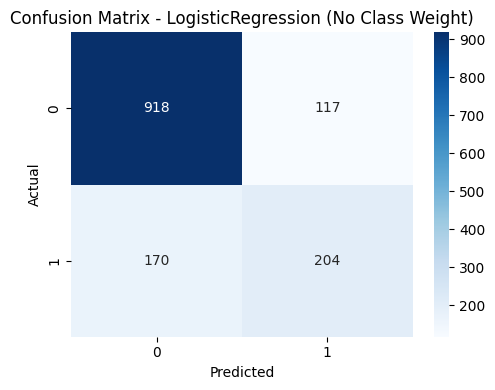

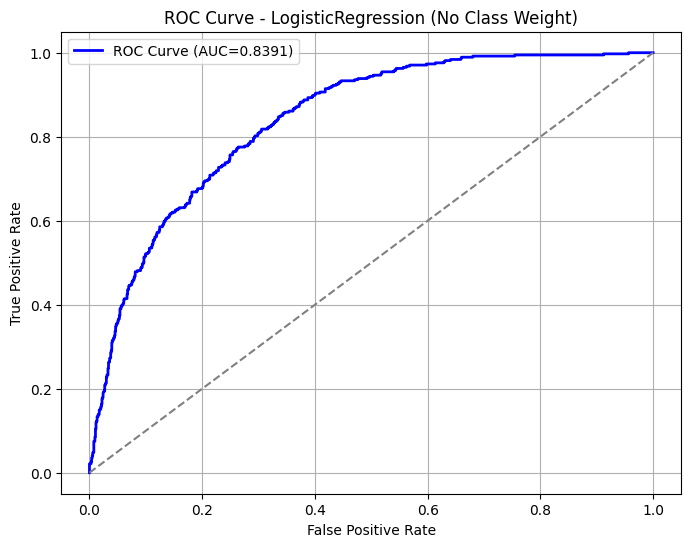

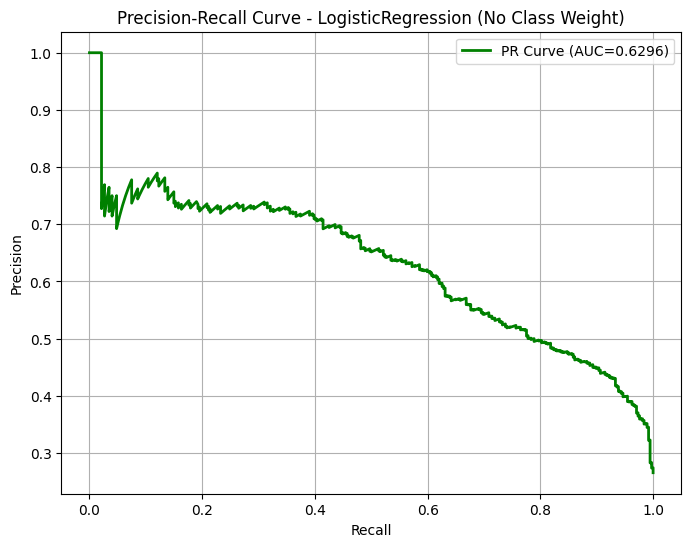

LogisticRegression (No Class Weight) metrics logged successfully!
Run ID: da2d2b45a38748dd90d2afffa90f11d8
Open MLflow UI in terminal: `mlflow ui`


In [25]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    classification_report, roc_auc_score, average_precision_score, 
    brier_score_loss, precision_recall_curve, roc_curve, auc
)
import matplotlib.pyplot as plt
import numpy as np
import json
import mlflow
import os


# -----------------------------
# Fit pipeline and predict
# -----------------------------
clf_lr_pipeline.fit(X_train, y_train)
y_pred_ncw = clf_lr_pipeline.predict(X_test)
y_probs_ncw = clf_lr_pipeline.predict_proba(X_test)[:, 1]  # probability of positive class

# -----------------------------
# Metrics
# -----------------------------
acc = accuracy_score(y_test, y_pred_ncw)
precision = precision_score(y_test, y_pred_ncw, zero_division=0)
recall = recall_score(y_test, y_pred_ncw, zero_division=0)
f1 = f1_score(y_test, y_pred_ncw, zero_division=0)
roc_auc = roc_auc_score(y_test, y_probs_ncw)
pr_auc = average_precision_score(y_test, y_probs_ncw)
from sklearn.metrics import confusion_matrix
import seaborn as sns

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred_ncw)
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - LogisticRegression (No Class Weight)")
plt.tight_layout()
cm_plot_file = "lr_pipeline_confusion_matrix.png"
plt.savefig(cm_plot_file)
plt.show()



# -----------------------------
# Curves
# -----------------------------
# ROC Curve
fpr, tpr, roc_thresh = roc_curve(y_test, y_probs_ncw)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC={roc_auc:.4f})', color='blue', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LogisticRegression (No Class Weight)')
plt.legend()
plt.grid(True)
plt.savefig("lr_pipeline_roc.png")
plt.show()

# Precision-Recall Curve
precision_vals, recall_vals, pr_thresh = precision_recall_curve(y_test, y_probs_ncw)
plt.figure(figsize=(8,6))
plt.plot(recall_vals, precision_vals, label=f'PR Curve (AUC={pr_auc:.4f})', color='green', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - LogisticRegression (No Class Weight)')
plt.legend()
plt.grid(True)
plt.savefig("lr_pipeline_pr.png")
plt.show()



with mlflow.start_run(run_name="LogisticRegression_NoClassWeight") as run:

    # Log parameters
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("class_weight", "None")
    mlflow.log_param("train_samples", len(X_train))
    mlflow.log_param("test_samples", len(X_test))
    
    # Log metrics
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)
    mlflow.log_metric("pr_auc", pr_auc)
    mlflow.log_metric("brier_score_loss", brier_score_loss(y_test, y_probs_ncw))
    
    # Log artifacts (plots)
    for plot_file in ["lr_pipeline_roc.png", "lr_pipeline_pr.png"]:
        if os.path.exists(plot_file):
            mlflow.log_artifact(plot_file, artifact_path="plots")
    
    # Log classification report
    report = classification_report(y_test, y_pred_ncw, output_dict=True)
    report_path = "classification_report_lr_ncw.json"
    with open(report_path, "w") as f:
        json.dump(report, f, indent=2)
    mlflow.log_artifact(report_path, artifact_path="reports")
    os.remove(report_path)
    
    # Optional tags
    mlflow.set_tag("stage", "evaluation")
    mlflow.set_tag("baseline_comparison", "No Class Weight")
    
    print("LogisticRegression (No Class Weight) metrics logged successfully!")
    print(f"Run ID: {run.info.run_id}")
    print("Open MLflow UI in terminal: `mlflow ui`")



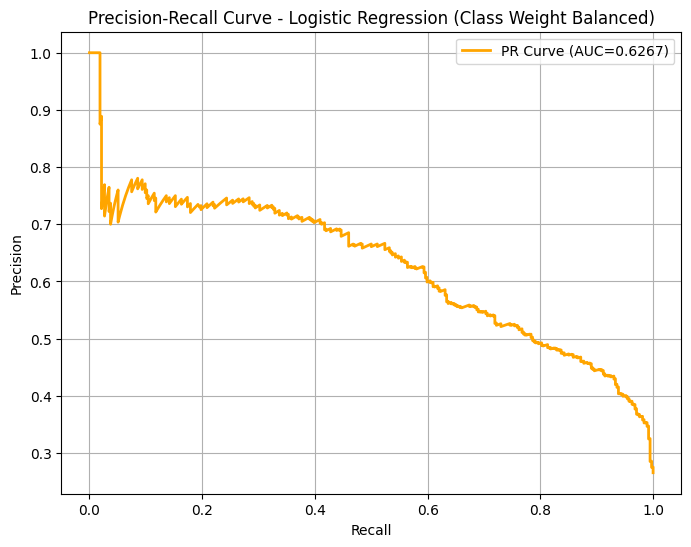

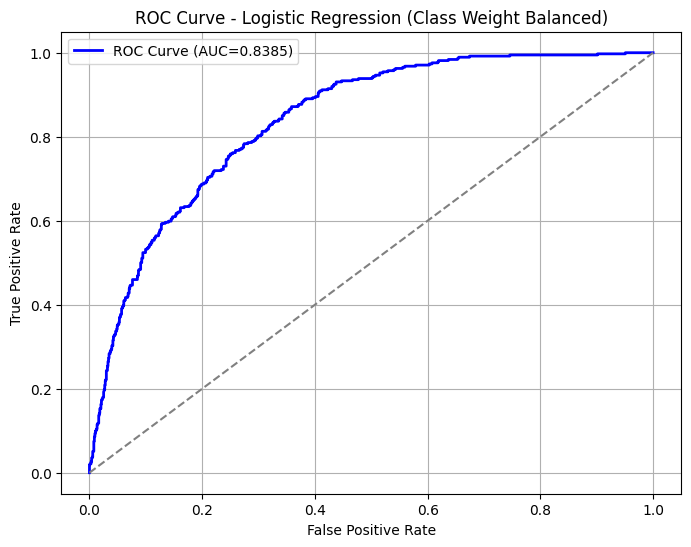

Confusion Matrix:
[[753 282]
 [ 85 289]]


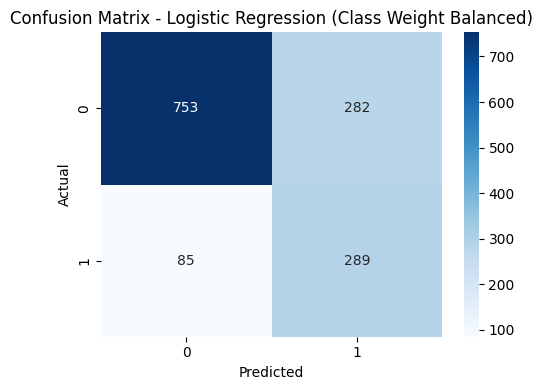

LogisticRegression (Class Weight Balanced) metrics logged successfully!
Run ID: cd229b675f684396a8f120880dd36a30
Open MLflow UI in terminal: `mlflow ui`


In [26]:
import mlflow
import numpy as np
import matplotlib.pyplot as plt
import json
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, precision_recall_curve, roc_curve, auc, roc_auc_score
)

# -----------------------------
# Fit pipeline and predict
# -----------------------------
clf_pipeline_lr_balanced.fit(X_train, y_train)
y_pred_balanced = clf_pipeline_lr_balanced.predict(X_test)
y_probs_balanced = clf_pipeline_lr_balanced.predict_proba(X_test)[:, 1]  # probability of positive class



# -----------------------------
# Compute PR curve and AUC
# -----------------------------
precision_vals, recall_vals, pr_thresh = precision_recall_curve(y_test, y_probs_balanced)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(8,6))
plt.plot(recall_vals, precision_vals, label=f'PR Curve (AUC={pr_auc:.4f})', color='orange', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Logistic Regression (Class Weight Balanced)')
plt.legend()
plt.grid(True)
plt.savefig("lr_balanced_pr_curve.png")
plt.show()  # display in notebook

# -----------------------------
# Compute ROC curve and AUC
# -----------------------------
fpr, tpr, roc_thresh = roc_curve(y_test, y_probs_balanced)
roc_auc = roc_auc_score(y_test, y_probs_balanced)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC={roc_auc:.4f})', color='blue', linewidth=2)
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression (Class Weight Balanced)')
plt.legend()
plt.grid(True)
plt.savefig("lr_balanced_roc_curve.png")
plt.show()  # display in notebook

# -----------------------------
# Compute basic metrics
# -----------------------------
acc = accuracy_score(y_test, y_pred_balanced)
precision = precision_score(y_test, y_pred_balanced, zero_division=0)
recall = recall_score(y_test, y_pred_balanced, zero_division=0)
f1 = f1_score(y_test, y_pred_balanced, zero_division=0)
cm = confusion_matrix(y_test, y_pred_balanced)
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression (Class Weight Balanced)")
plt.tight_layout()
cm_plot_file = "lr_balanced_confusion_matrix.png"
plt.savefig(cm_plot_file)
plt.show()

with mlflow.start_run(run_name="LogisticRegression_Balanced") as run:

    # Log parameters
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("train_samples", len(X_train))
    mlflow.log_param("test_samples", len(X_test))

    # Log metrics
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)
    mlflow.log_metric("pr_auc", pr_auc)
    mlflow.log_metric("brier_score_loss", brier_score_loss(y_test, y_probs_balanced))

    # Log artifacts (plots)
    for plot_file in ["lr_balanced_roc_curve.png", "lr_balanced_pr_curve.png"]:
        if os.path.exists(plot_file):
            mlflow.log_artifact(plot_file, artifact_path="plots")

    # Log classification report
    report = classification_report(y_test, y_pred_balanced, output_dict=True)
    report_path = "classification_report_lr_balanced.json"
    with open(report_path, "w") as f:
        json.dump(report, f, indent=2)
    mlflow.log_artifact(report_path, artifact_path="reports")
    os.remove(report_path)

    # Optional tags
    mlflow.set_tag("stage", "evaluation")
    mlflow.set_tag("baseline_comparison", "Class Weight Balanced")

    print("LogisticRegression (Class Weight Balanced) metrics logged successfully!")
    print(f"Run ID: {run.info.run_id}")
    print("Open MLflow UI in terminal: `mlflow ui`")



In [27]:
from sklearn.model_selection import GridSearchCV

# Grid of hyperparameters
param_grid = {
    'smote__k_neighbors': [3, 5, 7, 9,11],  # different SMOTE neighbors
}

# GridSearchCV with proper CV
grid_search = GridSearchCV(
    estimator=clf_lr_smote,
    param_grid=param_grid,
    scoring='average_precision',  # PR-AUC
    cv=5,
    n_jobs=-1
)

# Fit on training data
grid_search.fit(X_train, y_train)

# Best params
print("Best params:", grid_search.best_params_)
print("Best PR-AUC:", grid_search.best_score_)


Best params: {'smote__k_neighbors': 3}
Best PR-AUC: 0.6594422396920632


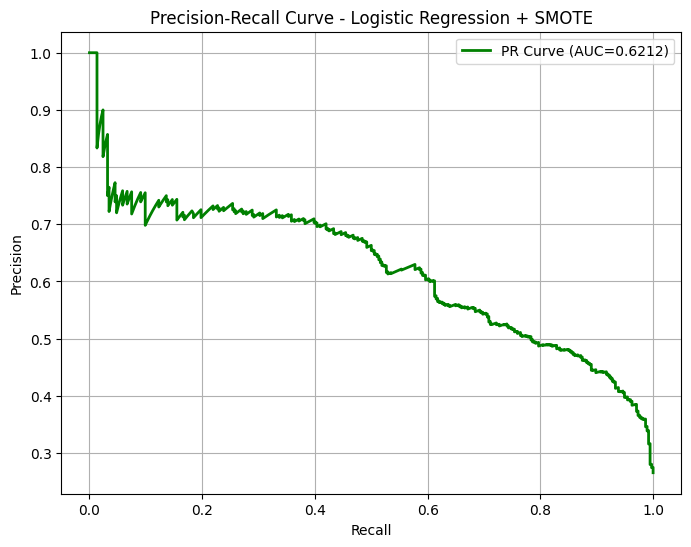

Confusion Matrix:
[[761 274]
 [ 89 285]]


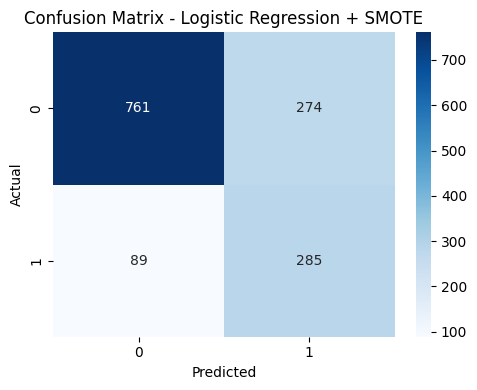

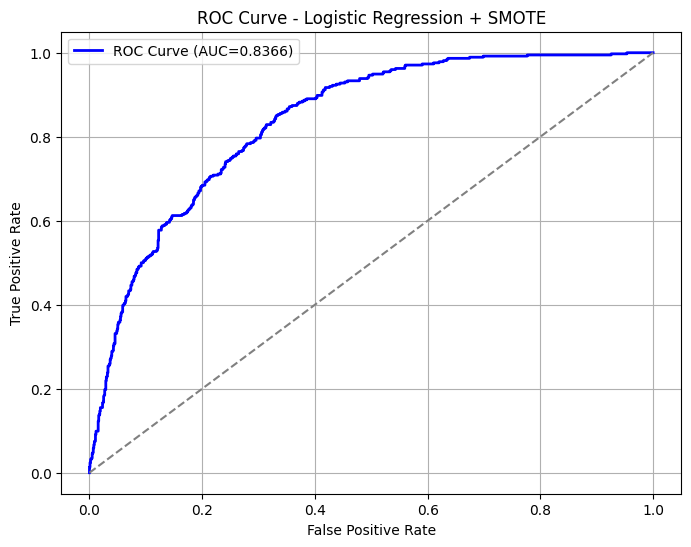

LogisticRegression + SMOTE metrics logged successfully!
Run ID: 7690bc940e2d4f36ae82033e132018fa
Open MLflow UI in terminal: `mlflow ui`


In [28]:
import mlflow
import numpy as np
import matplotlib.pyplot as plt
import json
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, precision_recall_curve, roc_curve, auc, roc_auc_score
)

# -----------------------------
# Use best estimator from GridSearchCV
# -----------------------------
best_pipeline = grid_search.best_estimator_

# Fit on training data (already fitted in GridSearchCV, but safe to call)
best_pipeline.fit(X_train, y_train)

# Predictions
y_pred_smote = best_pipeline.predict(X_test)
y_probs_smote = best_pipeline.predict_proba(X_test)[:, 1]  # probability of positive class


# -----------------------------
# Compute PR curve and AUC
# -----------------------------
precision_vals, recall_vals, pr_thresh = precision_recall_curve(y_test, y_probs_smote)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(8,6))
plt.plot(recall_vals, precision_vals, label=f'PR Curve (AUC={pr_auc:.4f})', color='green', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Logistic Regression + SMOTE')
plt.legend()
plt.grid(True)
plt.savefig("lr_smote_pr_curve.png")
plt.show()

# -----------------------------
# Compute ROC curve and AUC
# -----------------------------
fpr, tpr, roc_thresh = roc_curve(y_test, y_probs_smote)
roc_auc = roc_auc_score(y_test, y_probs_smote)
cm = confusion_matrix(y_test, y_pred_smote)
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression + SMOTE")
plt.tight_layout()
cm_plot_file = "lr_smote_confusion_matrix.png"
plt.savefig(cm_plot_file)
plt.show()

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC={roc_auc:.4f})', color='blue', linewidth=2)
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression + SMOTE')
plt.legend()
plt.grid(True)
plt.savefig("lr_smote_roc_curve.png")
plt.show()

# -----------------------------
# Compute basic metrics
# -----------------------------
acc = accuracy_score(y_test, y_pred_smote)
precision = precision_score(y_test, y_pred_smote, zero_division=0)
recall = recall_score(y_test, y_pred_smote, zero_division=0)
f1 = f1_score(y_test, y_pred_smote, zero_division=0)

with mlflow.start_run(run_name="LogisticRegression_SMOTE") as run:

    # Log parameters
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("sampling", "SMOTE")
    mlflow.log_param("train_samples", len(X_train))
    mlflow.log_param("test_samples", len(X_test))

    # Log metrics
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)
    mlflow.log_metric("pr_auc", pr_auc)
    mlflow.log_metric("brier_score_loss", brier_score_loss(y_test, y_probs_smote))

    # Log artifacts (plots)
    for plot_file in ["lr_smote_roc_curve.png", "lr_smote_pr_curve.png"]:
        if os.path.exists(plot_file):
            mlflow.log_artifact(plot_file, artifact_path="plots")

    # Log classification report
    report = classification_report(y_test, y_pred_smote, output_dict=True)
    report_path = "classification_report_lr_smote.json"
    with open(report_path, "w") as f:
        json.dump(report, f, indent=2)
    mlflow.log_artifact(report_path, artifact_path="reports")
    os.remove(report_path)

    # Optional tags
    mlflow.set_tag("stage", "evaluation")
    mlflow.set_tag("baseline_comparison", "SMOTE")

    print("LogisticRegression + SMOTE metrics logged successfully!")
    print(f"Run ID: {run.info.run_id}")
    print("Open MLflow UI in terminal: `mlflow ui`")



In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

# Store models and their predictions in a dictionary
models = {
    "LogReg_NoClassWeight": (y_pred_ncw, y_probs_ncw),  # from first pipeline
    "LogReg_Balanced": (y_pred_balanced, y_probs_balanced),  # from balanced pipeline
    "LogReg_SMOTE": (y_pred_smote, y_probs_smote)  # from SMOTE pipeline
}

# Initialize list to store metrics
metrics_list = []

for name, (y_pred_model, y_probs_model) in models.items():
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred_model),
        "Precision": precision_score(y_test, y_pred_model, zero_division=0),
        "Recall": recall_score(y_test, y_pred_model, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred_model, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_probs_model),
        "PR-AUC": average_precision_score(y_test, y_probs_model)
    }
    metrics_list.append(metrics)

# Create DataFrame
metrics_df = pd.DataFrame(metrics_list)
metrics_df.set_index("Model", inplace=True)
metrics_df


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Model,,,,,,
LogReg_NoClassWeight,0.796309,0.635514,0.545455,0.587050,0.839123,0.629628
LogReg_Balanced,0.739532,0.506130,0.772727,0.611640,0.838523,0.627738
LogReg_SMOTE,0.742370,0.509839,0.762032,0.610932,0.836635,0.622298


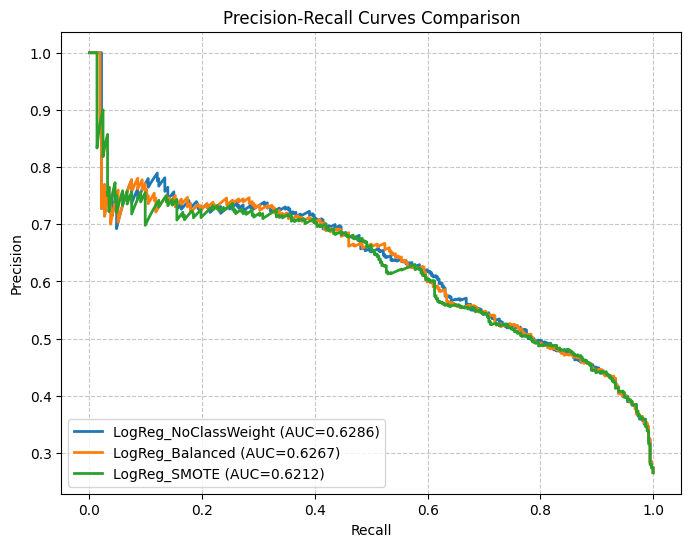

In [30]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Prepare PR curves for all models
models_pr = {
    "LogReg_NoClassWeight": (y_test, y_probs_ncw),
    "LogReg_Balanced": (y_test, y_probs_balanced),
    "LogReg_SMOTE": (y_test, y_probs_smote)
}

plt.figure(figsize=(8,6))

for name, (y_true, y_probs) in models_pr.items():
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_probs)
    pr_auc = auc(recall_vals, precision_vals)
    plt.plot(recall_vals, precision_vals, lw=2, label=f"{name} (AUC={pr_auc:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves Comparison")
plt.legend(loc="lower left")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


SInce the class weight balancing method worked better than Smote according to PR curve we will worh with the same method from here on.

In [31]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve, auc, make_scorer

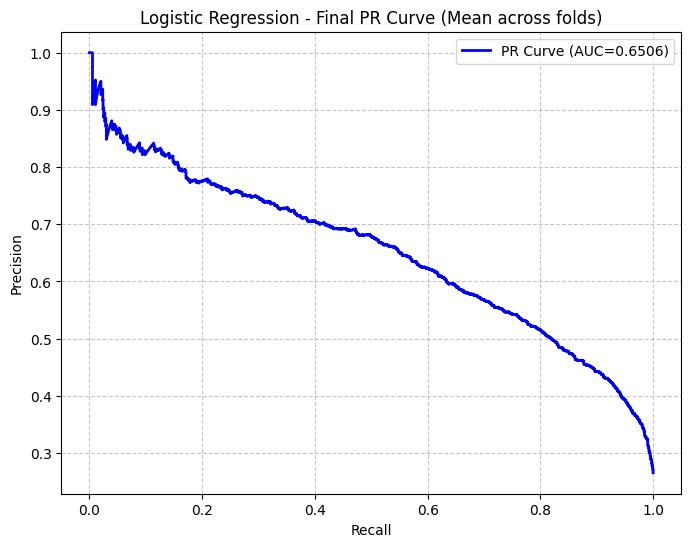

Confusion Matrix (Nested CV Logistic Regression):
[[3797 1377]
 [ 388 1481]]


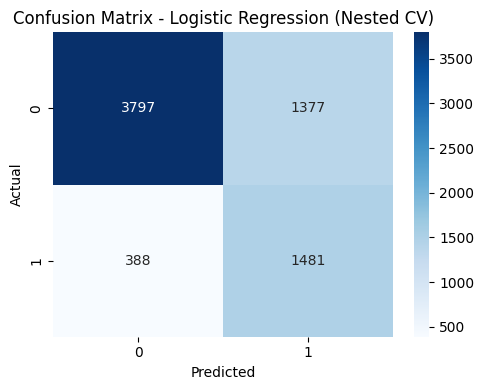

F1 and PR-AUC per fold for Logistic Regression (Δ = deviation from mean):

Fold 1: F1=0.6384 (Δ=+0.0118), PR-AUC=0.6586 (Δ=+0.0055)
Fold 2: F1=0.6315 (Δ=+0.0049), PR-AUC=0.6580 (Δ=+0.0050)
Fold 3: F1=0.6412 (Δ=+0.0146), PR-AUC=0.6925 (Δ=+0.0395)
Fold 4: F1=0.6047 (Δ=-0.0219), PR-AUC=0.6127 (Δ=-0.0403)
Fold 5: F1=0.6170 (Δ=-0.0095), PR-AUC=0.6433 (Δ=-0.0097)

Mean F1: 0.6266, Variance: 0.000189
Mean PR-AUC: 0.6530, Variance: 0.000666
Nested CV LogisticRegression metrics logged successfully!
Run ID: 27b46eb423b946db91092155304818c0
Open MLflow UI in terminal: `mlflow ui`


In [32]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    precision_recall_curve, average_precision_score
)
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# Pipeline and hyperparameters
# -------------------------------
logreg = Pipeline([
    ('preprocessor', preprocessor),  # your ColumnTransformer
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000))
])
param_logreg = {'model__C': [0.1, 1, 5, 10]}

# -------------------------------
# Nested CV setup
# -------------------------------
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Metrics storage
metrics_outer_lr = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'pr_auc': []}

# Store all fold predictions and probabilities for final PR curve
all_y_true_logreg = []
all_y_preds_logreg = []
all_y_probs_logreg = []

# -------------------------------
# Nested CV loop
# -------------------------------
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Inner loop: hyperparameter tuning
    grid = GridSearchCV(
        logreg, param_grid=param_logreg, cv=inner_cv, 
        scoring='average_precision', n_jobs=-1
    )
    grid.fit(X_train, y_train)

    # Predict probabilities & classes with model-specific names
    y_pred_logreg = grid.predict(X_test)
    y_prob_logreg = grid.predict_proba(X_test)[:, 1]

    # Compute metrics (store all)
    metrics_outer_lr['accuracy'].append(accuracy_score(y_test, y_pred_logreg))
    metrics_outer_lr['precision'].append(precision_score(y_test, y_pred_logreg))
    metrics_outer_lr['recall'].append(recall_score(y_test, y_pred_logreg))
    metrics_outer_lr['f1'].append(f1_score(y_test, y_pred_logreg))
    metrics_outer_lr['pr_auc'].append(average_precision_score(y_test, y_prob_logreg))

    # Collect predictions for final PR curve
    all_y_true_logreg.extend(y_test)
    all_y_preds_logreg.extend(y_pred_logreg)
    all_y_probs_logreg.extend(y_prob_logreg)

# -------------------------------
# Compute final mean PR curve
# -------------------------------
precision, recall, _ = precision_recall_curve(all_y_true_logreg, all_y_probs_logreg)
final_pr_auc = average_precision_score(all_y_true_logreg, all_y_probs_logreg)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, color='blue', lw=2, label=f'PR Curve (AUC={final_pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Logistic Regression - Final PR Curve (Mean across folds)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

cm = confusion_matrix(all_y_true_logreg, all_y_preds_logreg)
print("Confusion Matrix (Nested CV Logistic Regression):")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression (Nested CV)")
plt.tight_layout()
cm_plot_file = "logreg_nestedcv_confusion_matrix.png"
plt.savefig(cm_plot_file)
plt.show()
# -------------------------------
# Summary of F1 and PR-AUC with variance
# -------------------------------
f1_vals = np.array(metrics_outer_lr['f1'])
pr_auc_vals = np.array(metrics_outer_lr['pr_auc'])
f1_mean = np.mean(f1_vals)
pr_auc_mean = np.mean(pr_auc_vals)

print("F1 and PR-AUC per fold for Logistic Regression (Δ = deviation from mean):\n")
for i in range(outer_cv.n_splits):
    f1_dev = f1_vals[i] - f1_mean
    pr_auc_dev = pr_auc_vals[i] - pr_auc_mean
    print(f"Fold {i+1}: F1={f1_vals[i]:.4f} (Δ={f1_dev:+.4f}), PR-AUC={pr_auc_vals[i]:.4f} (Δ={pr_auc_dev:+.4f})")

print(f"\nMean F1: {f1_mean:.4f}, Variance: {np.var(f1_vals):.6f}")
print(f"Mean PR-AUC: {pr_auc_mean:.4f}, Variance: {np.var(pr_auc_vals):.6f}")

with mlflow.start_run(run_name="LogisticRegression_NestedCV") as run:

    # Log parameters
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("outer_cv_splits", 5)
    mlflow.log_param("inner_cv_splits", 3)
    mlflow.log_param("C_values_tested", json.dumps([0.1, 1, 5, 10]))
    mlflow.log_param("train_samples", len(X))
    mlflow.log_param("scoring_metric", "average_precision")

    # Log metrics: mean and variance
    mlflow.log_metric("f1_mean", f1_mean)
    mlflow.log_metric("f1_variance", np.var(f1_vals))
    mlflow.log_metric("pr_auc_mean", pr_auc_mean)
    mlflow.log_metric("pr_auc_variance", np.var(pr_auc_vals))

    # Log per-fold metrics
    for i in range(outer_cv.n_splits):
        mlflow.log_metric(f"f1_fold_{i+1}", f1_vals[i])
        mlflow.log_metric(f"pr_auc_fold_{i+1}", pr_auc_vals[i])

    # Log final PR curve as artifact
    pr_curve_path = "logreg_nestedcv_pr_curve.png"
    plt.figure(figsize=(8,6))
    plt.plot(recall, precision, color='blue', lw=2, label=f'PR Curve (AUC={final_pr_auc:.4f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Logistic Regression - Final PR Curve (Mean across folds)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.savefig(pr_curve_path)
    plt.close()
    if os.path.exists(pr_curve_path):
        mlflow.log_artifact(pr_curve_path, artifact_path="plots")

    # Log classification report for all predictions as artifact
    report = classification_report(all_y_true_logreg, all_y_preds_logreg, output_dict=True)
    report_path = "classification_report_logreg_nestedcv.json"
    with open(report_path, "w") as f:
        json.dump(report, f, indent=2)
    mlflow.log_artifact(report_path, artifact_path="reports")
    os.remove(report_path)

    # Optional tags
    mlflow.set_tag("stage", "evaluation")
    mlflow.set_tag("cross_validation", "nested")

    print("Nested CV LogisticRegression metrics logged successfully!")
    print(f"Run ID: {run.info.run_id}")
    print("Open MLflow UI in terminal: `mlflow ui`")


Starting nested cross-validation for XGBoost...

Processing outer fold 1/5...


c:\Users\Acer\Desktop\projects\week_2\churn_env\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:10:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 1 → F1: 0.6127, PR-AUC: 0.6829
Best hyperparameters for this fold: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__scale_pos_weight': 1}

Processing outer fold 2/5...


c:\Users\Acer\Desktop\projects\week_2\churn_env\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:10:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 2 → F1: 0.6027, PR-AUC: 0.6620
Best hyperparameters for this fold: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__scale_pos_weight': 5}

Processing outer fold 3/5...


c:\Users\Acer\Desktop\projects\week_2\churn_env\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:10:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 3 → F1: 0.5944, PR-AUC: 0.6821
Best hyperparameters for this fold: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__scale_pos_weight': 1}

Processing outer fold 4/5...


c:\Users\Acer\Desktop\projects\week_2\churn_env\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:10:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 4 → F1: 0.5505, PR-AUC: 0.6234
Best hyperparameters for this fold: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__scale_pos_weight': 1}

Processing outer fold 5/5...
Fold 5 → F1: 0.5818, PR-AUC: 0.6609
Best hyperparameters for this fold: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__scale_pos_weight': 1}



c:\Users\Acer\Desktop\projects\week_2\churn_env\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:10:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


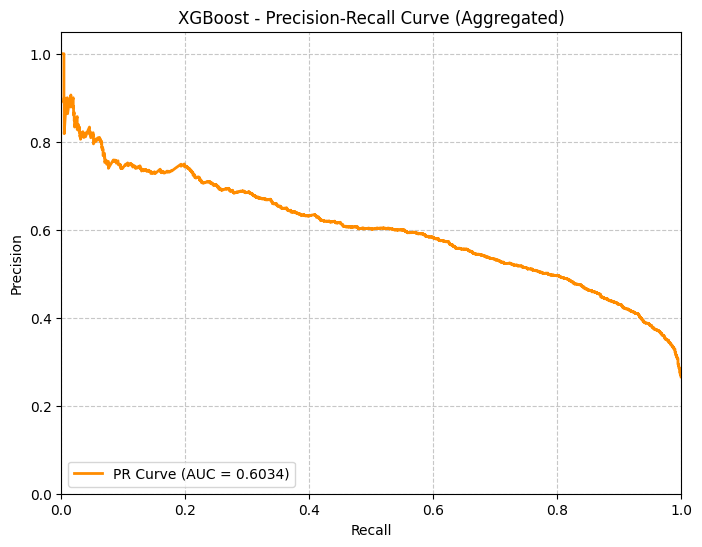

NESTED CV RESULTS - XGBoost
Fold 1: F1 = 0.6127 (Δ = +0.0243) | PR-AUC = 0.6829 (Δ = +0.0206)
Fold 2: F1 = 0.6027 (Δ = +0.0143) | PR-AUC = 0.6620 (Δ = -0.0002)
Fold 3: F1 = 0.5944 (Δ = +0.0060) | PR-AUC = 0.6821 (Δ = +0.0199)
Fold 4: F1 = 0.5505 (Δ = -0.0379) | PR-AUC = 0.6234 (Δ = -0.0389)
Fold 5: F1 = 0.5818 (Δ = -0.0066) | PR-AUC = 0.6609 (Δ = -0.0014)

Mean F1     : 0.5884 ± var 0.000462
Mean PR-AUC : 0.6623 ± var 0.000467

Using best hyperparameters from last fold to retrain full model:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__scale_pos_weight': 1}
Confusion Matrix (Nested CV XGBoost):
[[4378  796]
 [ 753 1116]]


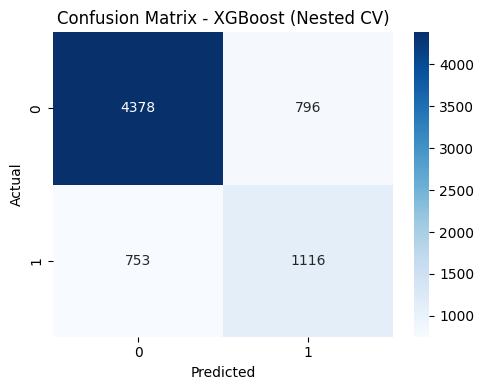

Nested CV XGBoost metrics logged successfully!
Run ID: f03f29e9e38447edaf61f26903552b44
Open MLflow UI in terminal: `mlflow ui`


In [33]:
# =============================
# IMPORTS
# =============================
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# =============================
# PIPELINE AND HYPERPARAMETERS
# =============================
xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),  # Make sure 'preprocessor' is defined earlier
    ('model', XGBClassifier(
        eval_metric='logloss',
        use_label_encoder=False,  # important for newer versions
        random_state=42
    ))
])

param_xgb = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 6],
    'model__learning_rate': [0.01, 0.1],
    'model__scale_pos_weight': [1, 5, 10]
}

# =============================
# NESTED CROSS-VALIDATION SETUP
# =============================
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

metrics_outer_xgb = {'f1': [], 'pr_auc': []}
all_y_true_xgb, all_y_preds_xgb, all_y_probs_xgb = [], [], []

print("Starting nested cross-validation for XGBoost...\n")
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):
    print(f"Processing outer fold {fold}/5...")
    
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
    
    # Inner CV: Hyperparameter tuning
    grid = GridSearchCV(
        estimator=xgb_pipe,
        param_grid=param_xgb,
        cv=inner_cv,
        scoring='average_precision',
        n_jobs=-1,
        refit=True
    )
    grid.fit(X_train_fold, y_train_fold)
    
    best_model_fold = grid.best_estimator_
    
    # Predictions on outer test fold
    y_pred = best_model_fold.predict(X_test_fold)
    y_prob = best_model_fold.predict_proba(X_test_fold)[:, 1]
    
    # Metrics
    f1 = f1_score(y_test_fold, y_pred)
    pr_auc = average_precision_score(y_test_fold, y_prob)
    
    metrics_outer_xgb['f1'].append(f1)
    metrics_outer_xgb['pr_auc'].append(pr_auc)
    
    all_y_true_xgb.extend(y_test_fold)
    all_y_preds_xgb.extend(y_pred)
    all_y_probs_xgb.extend(y_prob)
    
    print(f"Fold {fold} → F1: {f1:.4f}, PR-AUC: {pr_auc:.4f}")
    print(f"Best hyperparameters for this fold: {grid.best_params_}\n")

# =============================
# FINAL PR CURVE AGGREGATED
# =============================
precision, recall, _ = precision_recall_curve(all_y_true_xgb, all_y_probs_xgb)
final_pr_auc = average_precision_score(all_y_true_xgb, all_y_probs_xgb)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkorange', lw=2,
         label=f'PR Curve (AUC = {final_pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('XGBoost - Precision-Recall Curve (Aggregated)')
plt.legend(loc="lower left")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.show()

# =============================
# SUMMARY OF METRICS
# =============================
f1_vals = metrics_outer_xgb['f1']
pr_auc_vals = metrics_outer_xgb['pr_auc']

f1_mean, pr_auc_mean = np.mean(f1_vals), np.mean(pr_auc_vals)
f1_var, pr_auc_var = np.var(f1_vals), np.var(pr_auc_vals)

print("="*60)
print("NESTED CV RESULTS - XGBoost")
print("="*60)
for i in range(outer_cv.n_splits):
    print(f"Fold {i+1}: F1 = {f1_vals[i]:.4f} (Δ = {f1_vals[i]-f1_mean:+.4f}) | "
          f"PR-AUC = {pr_auc_vals[i]:.4f} (Δ = {pr_auc_vals[i]-pr_auc_mean:+.4f})")

print(f"\nMean F1     : {f1_mean:.4f} ± var {f1_var:.6f}")
print(f"Mean PR-AUC : {pr_auc_mean:.4f} ± var {pr_auc_var:.6f}")
print("="*60)

# =============================
# TRAIN BEST PIPELINE ON FULL DATA
# =============================
best_params = grid.best_params_
print("\nUsing best hyperparameters from last fold to retrain full model:")
print(best_params)

cm = confusion_matrix(all_y_true_xgb, all_y_preds_xgb)
print("Confusion Matrix (Nested CV XGBoost):")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost (Nested CV)")
plt.tight_layout()
cm_plot_file = "xgb_nestedcv_confusion_matrix.png"
plt.savefig(cm_plot_file)
plt.show()



with mlflow.start_run(run_name="XGBoost_NestedCV") as run:

    # Log parameters
    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("outer_cv_splits", 5)
    mlflow.log_param("inner_cv_splits", 3)
    mlflow.log_param("hyperparameter_grid", json.dumps(param_xgb))
    mlflow.log_param("train_samples", len(X))
    mlflow.log_param("scoring_metric", "average_precision")

    # Log metrics: mean and variance
    mlflow.log_metric("f1_mean", f1_mean)
    mlflow.log_metric("f1_variance", f1_var)
    mlflow.log_metric("pr_auc_mean", pr_auc_mean)
    mlflow.log_metric("pr_auc_variance", pr_auc_var)

    # Log per-fold metrics
    for i in range(outer_cv.n_splits):
        mlflow.log_metric(f"f1_fold_{i+1}", f1_vals[i])
        mlflow.log_metric(f"pr_auc_fold_{i+1}", pr_auc_vals[i])

    # Log final PR curve as artifact
    pr_curve_path = "xgb_nestedcv_pr_curve.png"
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='darkorange', lw=2,
             label=f'PR Curve (AUC = {final_pr_auc:.4f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('XGBoost - Precision-Recall Curve (Aggregated)')
    plt.legend(loc="lower left")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.savefig(pr_curve_path)
    plt.close()
    if os.path.exists(pr_curve_path):
        mlflow.log_artifact(pr_curve_path, artifact_path="plots")

    # Log classification report for all predictions
    report = classification_report(all_y_true_xgb, all_y_preds_xgb, output_dict=True)
    report_path = "classification_report_xgb_nestedcv.json"
    with open(report_path, "w") as f:
        json.dump(report, f, indent=2)
    mlflow.log_artifact(report_path, artifact_path="reports")
    os.remove(report_path)

    # Log best hyperparameters from last fold
    for key, value in best_params.items():
        mlflow.log_param(f"best_{key}", value)

    # Optional tags
    mlflow.set_tag("stage", "evaluation")
    mlflow.set_tag("cross_validation", "nested")

    print("Nested CV XGBoost metrics logged successfully!")
    print(f"Run ID: {run.info.run_id}")
    print("Open MLflow UI in terminal: `mlflow ui`")


Starting nested cross-validation for Random Forest...

Processing outer fold 1/5...
Fold 1 → F1: 0.6254, PR-AUC: 0.6499

Processing outer fold 2/5...
Fold 2 → F1: 0.6219, PR-AUC: 0.6363

Processing outer fold 3/5...
Fold 3 → F1: 0.6544, PR-AUC: 0.6909

Processing outer fold 4/5...
Fold 4 → F1: 0.5972, PR-AUC: 0.6042

Processing outer fold 5/5...
Fold 5 → F1: 0.6157, PR-AUC: 0.6395



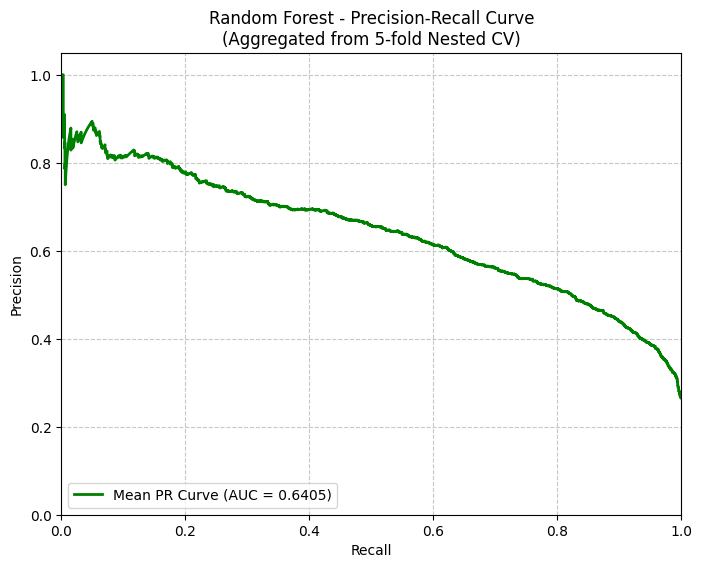

NESTED CV RESULTS - Random Forest
F1 and PR-AUC per outer fold (Δ = deviation from mean):

Fold 1:  F1 = 0.6254 (Δ = +0.0025)  |  PR-AUC = 0.6499 (Δ = +0.0058)
Fold 2:  F1 = 0.6219 (Δ = -0.0011)  |  PR-AUC = 0.6363 (Δ = -0.0079)
Fold 3:  F1 = 0.6544 (Δ = +0.0315)  |  PR-AUC = 0.6909 (Δ = +0.0467)
Fold 4:  F1 = 0.5972 (Δ = -0.0258)  |  PR-AUC = 0.6042 (Δ = -0.0400)
Fold 5:  F1 = 0.6157 (Δ = -0.0072)  |  PR-AUC = 0.6395 (Δ = -0.0047)

------------------------------------------------------------
Mean F1     : 0.6229 ± var 0.000343
Mean PR-AUC : 0.6442 ± var 0.000780


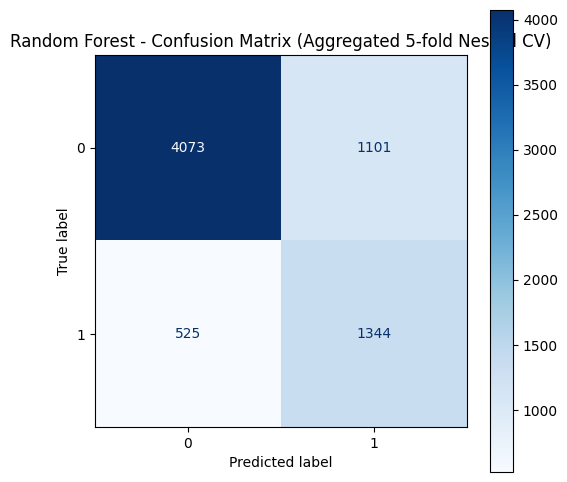

Nested CV Random Forest metrics logged successfully!
Run ID: 8efb2439ea5f4c5185651d5e7f2642d8
Open MLflow UI in terminal: `mlflow ui`


In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# =============================
# Random Forest Pipeline & Hyperparameters
# =============================
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),  # Your defined ColumnTransformer
    ('model', RandomForestClassifier(
        class_weight='balanced',
        random_state=42,             # For reproducibility
        n_jobs=-1                    # Speed up training
    ))
])

param_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

# =============================
# Nested Cross-Validation Setup
# =============================
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Storage for outer fold metrics
metrics_outer_rf = {'f1': [], 'pr_auc': []}

# Storage for concatenated predictions (for final mean PR curve)
all_y_true_rf = []
all_y_preds_rf = []
all_y_probs_rf = []

# =============================
# Nested CV Loop
# =============================
print("Starting nested cross-validation for Random Forest...\n")
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):
    print(f"Processing outer fold {fold}/5...")
    
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # -----------------------------
    # Inner CV: Hyperparameter tuning (optimize for PR-AUC)
    # -----------------------------
    grid = GridSearchCV(
        estimator=rf_pipe,
        param_grid=param_rf,
        cv=inner_cv,
        scoring='average_precision',
        n_jobs=-1,
        refit=True
    )
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    
    # -----------------------------
    # Predictions on outer test fold
    # -----------------------------
    y_pred_rf = best_model.predict(X_test)
    y_prob_rf = best_model.predict_proba(X_test)[:, 1]
    
    # -----------------------------
    # Metrics for this fold
    # -----------------------------
    f1 = f1_score(y_test, y_pred_rf)
    pr_auc = average_precision_score(y_test, y_prob_rf)
    
    metrics_outer_rf['f1'].append(f1)
    metrics_outer_rf['pr_auc'].append(pr_auc)
    
    # Collect for final aggregated PR curve
    all_y_true_rf.extend(y_test)
    all_y_preds_rf.extend(y_pred_rf)
    all_y_probs_rf.extend(y_prob_rf)
    
    print(f"Fold {fold} → F1: {f1:.4f}, PR-AUC: {pr_auc:.4f}\n")

# =============================
# Final Aggregated PR Curve (across all outer folds)
# =============================
precision, recall, _ = precision_recall_curve(all_y_true_rf, all_y_probs_rf)
final_pr_auc = average_precision_score(all_y_true_rf, all_y_probs_rf)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', lw=2,
         label=f'Mean PR Curve (AUC = {final_pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Random Forest - Precision-Recall Curve\n(Aggregated from 5-fold Nested CV)')
plt.legend(loc="lower left")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.show()

# =============================
# Summary: F1 and PR-AUC per fold + variance
# =============================
f1_vals = metrics_outer_rf['f1']
pr_auc_vals = metrics_outer_rf['pr_auc']

f1_mean = np.mean(f1_vals)
pr_auc_mean = np.mean(pr_auc_vals)
f1_var = np.var(f1_vals)
pr_auc_var = np.var(pr_auc_vals)

print("="*60)
print("NESTED CV RESULTS - Random Forest")
print("="*60)
print("F1 and PR-AUC per outer fold (Δ = deviation from mean):\n")

for i in range(outer_cv.n_splits):
    f1_dev = f1_vals[i] - f1_mean
    pr_auc_dev = pr_auc_vals[i] - pr_auc_mean
    print(f"Fold {i+1}:  F1 = {f1_vals[i]:.4f} (Δ = {f1_dev:+.4f})  |  "
          f"PR-AUC = {pr_auc_vals[i]:.4f} (Δ = {pr_auc_dev:+.4f})")

print("\n" + "-"*60)
print(f"Mean F1     : {f1_mean:.4f} ± var {f1_var:.6f}")
print(f"Mean PR-AUC : {pr_auc_mean:.4f} ± var {pr_auc_var:.6f}")
print("="*60)

cm = confusion_matrix(all_y_true_rf, all_y_preds_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])  # adjust labels if needed

plt.figure(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=plt.gca())
plt.title("Random Forest - Confusion Matrix (Aggregated 5-fold Nested CV)")
plt.grid(False)
plt.savefig("rf_nestedcv_confusion_matrix.png")
plt.show()
with mlflow.start_run(run_name="RandomForest_NestedCV") as run:

    # -----------------------------
    # Log parameters
    # -----------------------------
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("outer_cv_splits", 5)
    mlflow.log_param("inner_cv_splits", 3)
    mlflow.log_param("hyperparameter_grid", json.dumps(param_rf))
    mlflow.log_param("train_samples", len(X))
    mlflow.log_param("scoring_metric", "average_precision")
    mlflow.log_param("class_weight", "balanced")

    # -----------------------------
    # Log metrics: mean and variance
    # -----------------------------
    mlflow.log_metric("f1_mean", f1_mean)
    mlflow.log_metric("f1_variance", f1_var)
    mlflow.log_metric("pr_auc_mean", pr_auc_mean)
    mlflow.log_metric("pr_auc_variance", pr_auc_var)

    # -----------------------------
    # Log per-fold metrics
    # -----------------------------
    for i in range(outer_cv.n_splits):
        mlflow.log_metric(f"f1_fold_{i+1}", f1_vals[i])
        mlflow.log_metric(f"pr_auc_fold_{i+1}", pr_auc_vals[i])

    # -----------------------------
    # Log final aggregated PR curve
    # -----------------------------
    pr_curve_path = "rf_nestedcv_pr_curve.png"
    precision, recall, _ = precision_recall_curve(all_y_true_rf, all_y_probs_rf)
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='green', lw=2,
             label=f'Mean PR Curve (AUC = {final_pr_auc:.4f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Random Forest - PR Curve (Aggregated 5-fold Nested CV)')
    plt.legend(loc="lower left")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.savefig(pr_curve_path)
    plt.close()

    
    if os.path.exists(pr_curve_path):
        mlflow.log_artifact(pr_curve_path, artifact_path="plots")

    # -----------------------------
    # Log classification report for all predictions
    # -----------------------------
    report = classification_report(all_y_true_rf, all_y_preds_rf, output_dict=True)
    report_path = "classification_report_rf_nestedcv.json"
    with open(report_path, "w") as f:
        json.dump(report, f, indent=2)
    mlflow.log_artifact(report_path, artifact_path="reports")
    os.remove(report_path)

    # -----------------------------
    # Log best hyperparameters from last fold
    # -----------------------------
    for key, value in grid.best_params_.items():
        mlflow.log_param(f"best_{key}", value)

    # -----------------------------
    # Optional tags
    # -----------------------------
    mlflow.set_tag("stage", "evaluation")
    mlflow.set_tag("cross_validation", "nested")

    print("Nested CV Random Forest metrics logged successfully!")
    print(f"Run ID: {run.info.run_id}")
    print("Open MLflow UI in terminal: `mlflow ui`")

In [ ]:
import pandas as pd

# =============================
# COMPARISON OF ALL MODELS
# =============================

# Collect mean and variance for each model
comparison_data = {
    'Model': [],
    'Mean F1': [],
    'F1 Variance': [],
    'Mean PR-AUC': [],
    'PR-AUC Variance': []
}

# --- Add Logistic Regression (if you have it) ---
comparison_data['Model'].append('Logistic Regression')
comparison_data['Mean F1'].append(np.mean(metrics_outer_lr['f1']))
comparison_data['F1 Variance'].append(np.var(metrics_outer_lr['f1']))
comparison_data['Mean PR-AUC'].append(np.mean(metrics_outer_lr['pr_auc']))
comparison_data['PR-AUC Variance'].append(np.var(metrics_outer_lr['pr_auc']))

# --- Add XGBoost ---
comparison_data['Model'].append('XGBoost')
comparison_data['Mean F1'].append(np.mean(metrics_outer_xgb['f1']))
comparison_data['F1 Variance'].append(np.var(metrics_outer_xgb['f1']))
comparison_data['Mean PR-AUC'].append(np.mean(metrics_outer_xgb['pr_auc']))
comparison_data['PR-AUC Variance'].append(np.var(metrics_outer_xgb['pr_auc']))

# --- Add Random Forest ---
comparison_data['Model'].append('Random Forest')
comparison_data['Mean F1'].append(np.mean(metrics_outer_rf['f1']))
comparison_data['F1 Variance'].append(np.var(metrics_outer_rf['f1']))
comparison_data['Mean PR-AUC'].append(np.mean(metrics_outer_rf['pr_auc']))
comparison_data['PR-AUC Variance'].append(np.var(metrics_outer_rf['pr_auc']))

# Create DataFrame and sort by Mean PR-AUC (best first)
df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.sort_values('Mean PR-AUC', ascending=False).reset_index(drop=True)

# Round nicely
df_comparison['Mean F1'] = df_comparison['Mean F1'].round(4)
df_comparison['F1 Variance'] = df_comparison['F1 Variance'].round(6)
df_comparison['Mean PR-AUC'] = df_comparison['Mean PR-AUC'].round(4)
df_comparison['PR-AUC Variance'] = df_comparison['PR-AUC Variance'].round(6)

# =============================
# FINAL COMPARISON TABLE
# =============================
print("\n" + "="*80)
print("NESTED CV MODEL COMPARISON (5-fold outer)")
print("="*80)
print(df_comparison.to_string(index=False))
print("="*80)

# Highlight the winner
best_model = df_comparison.iloc[0]['Model']
best_prauc = df_comparison.iloc[0]['Mean PR-AUC']
print(f"\nWinner by Mean PR-AUC: {best_model} (PR-AUC = {best_prauc:.4f})\n")

# Here Since Xgboost is better in pr-auc and variance (more stable too) and also almost similar score in f1 we select Xgboost model. 

# Day4



SHAP EXPLAINABILITY ON FINAL XGBoost MODEL (refit on full data)
Performing final GridSearchCV on 100% of data to select best hyperparameters...


c:\Users\Acer\Desktop\projects\week_2\churn_env\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:15:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Acer\AppData\Local\Temp\ipykernel_5800\3496013497.py:72: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


Best hyperparameters found on full data:
  model__learning_rate: 0.1
  model__max_depth: 3
  model__n_estimators: 100
  model__scale_pos_weight: 1
Best inner CV PR-AUC: 0.6618

Computing SHAP values using TreeExplainer (this may take 30–90 seconds)...
Expected value (base value): -1.0430


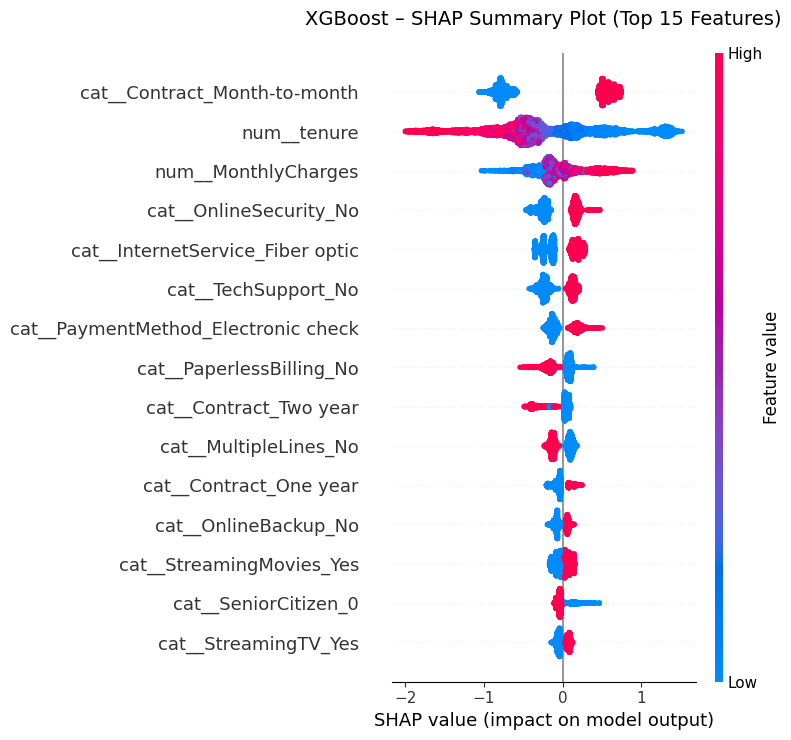

C:\Users\Acer\AppData\Local\Temp\ipykernel_5800\3496013497.py:86: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


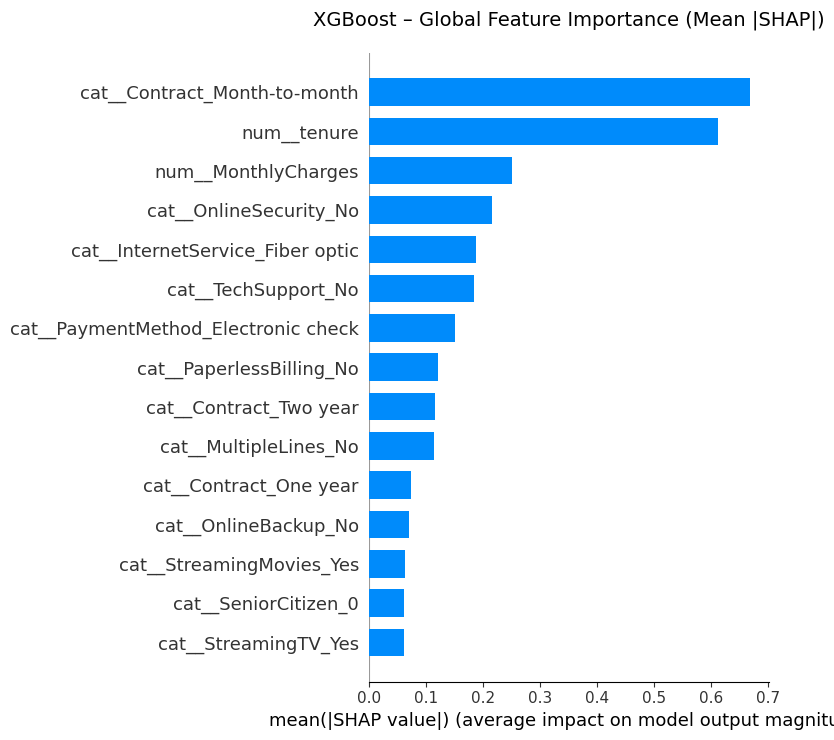


Top 15 Most Important Features (by mean |SHAP value|):
                            feature  mean_|SHAP|
       cat__Contract_Month-to-month     0.668363
                        num__tenure     0.613169
                num__MonthlyCharges     0.250580
             cat__OnlineSecurity_No     0.216104
   cat__InternetService_Fiber optic     0.188436
                cat__TechSupport_No     0.184460
cat__PaymentMethod_Electronic check     0.152306
           cat__PaperlessBilling_No     0.121574
             cat__Contract_Two year     0.117251
              cat__MultipleLines_No     0.113827
             cat__Contract_One year     0.074855
               cat__OnlineBackup_No     0.070320
           cat__StreamingMovies_Yes     0.064457
               cat__SeniorCitizen_0     0.062557
               cat__StreamingTV_Yes     0.062533

Top 10 features saved → ['cat__Contract_Month-to-month', 'num__tenure', 'num__MonthlyCharges', 'cat__OnlineSecurity_No', 'cat__InternetService_Fiber optic', 'c

<Figure size 800x500 with 0 Axes>

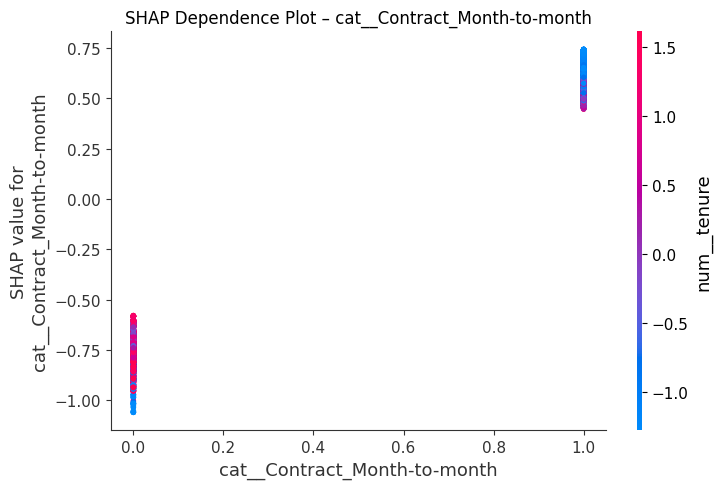

In [35]:
# =============================
# SHAP EXPLAINABILITY – XGBoost (Best Model)
# =============================
import shap
import pandas as pd
import matplotlib.pyplot as plt

print("\n" + "="*70)
print("SHAP EXPLAINABILITY ON FINAL XGBoost MODEL (refit on full data)")
print("="*70)

# Re-build the XGBoost pipeline
final_xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    ))
])

# Full hyperparameter search on the entire dataset to get the absolute best config
print("Performing final GridSearchCV on 100% of data to select best hyperparameters...")
full_grid = GridSearchCV(
    estimator=final_xgb_pipe,
    param_grid=param_xgb,
    cv=inner_cv,                    # same 3-fold inner CV as before
    scoring='average_precision',
    n_jobs=-1,
    refit=True
)

full_grid.fit(X, y)
final_xgb = full_grid.best_estimator_

print(f"Best hyperparameters found on full data:")
for k, v in full_grid.best_params_.items():
    print(f"  {k}: {v}")
print(f"Best inner CV PR-AUC: {full_grid.best_score_:.4f}")

# =============================
# Prepare data for SHAP (critical: correct feature names!)
# =============================
X_processed = final_xgb.named_steps['preprocessor'].transform(X)
feature_names = final_xgb.named_steps['preprocessor'].get_feature_names_out()

X_shap = pd.DataFrame(X_processed, columns=feature_names)

# =============================
# SHAP Explainer (TreeExplainer is fast & exact for XGBoost)
# =============================
print("\nComputing SHAP values using TreeExplainer (this may take 30–90 seconds)...")
explainer = shap.TreeExplainer(final_xgb.named_steps['model'])

# For binary classification, we want SHAP values for the positive class
shap_values = explainer.shap_values(X_shap)           # shape: (n_samples, n_features)
expected_value = explainer.expected_value

# XGBoost sometimes returns a single array (log-odds), sometimes list → normalize
if isinstance(shap_values, list):
    shap_values = shap_values[1]      # positive class
if isinstance(expected_value, (np.ndarray, list)):
    expected_value = expected_value[1] if len(expected_value) > 1 else expected_value[0]

print(f"Expected value (base value): {expected_value:.4f}")

# =============================
# 1. SHAP Summary Plot (Beeswarm) – The gold standard
# =============================
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_shap,
    plot_type="dot",
    max_display=15,
    show=False
)
plt.title("XGBoost – SHAP Summary Plot (Top 15 Features)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# =============================
# 2. Bar Plot – Mean Absolute SHAP Value (Global Importance)
# =============================
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values, X_shap,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("XGBoost – Global Feature Importance (Mean |SHAP|)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# =============================
# 3. Top 15 Features Table
# =============================
shap_importance = pd.DataFrame({
    'feature': feature_names,
    'mean_|SHAP|': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_|SHAP|', ascending=False).head(15).reset_index(drop=True)

print("\nTop 15 Most Important Features (by mean |SHAP value|):")
print(shap_importance.to_string(index=False, float_format="%.6f"))

# Save for later use (calibration plots, reports, etc.)
top_10_features = shap_importance['feature'].head(10).tolist()
print(f"\nTop 10 features saved → {top_10_features}")

# Optional: quick dependence plot for the #1 feature
top_feature = shap_importance.iloc[0]['feature']
plt.figure(figsize=(8, 5))
shap.dependence_plot(top_feature, shap_values, X_shap, show=False)
plt.title(f"SHAP Dependence Plot – {top_feature}")
plt.tight_layout()
plt.show()

In [36]:
shap_values.shape

(7043, 45)

If customer has no month to month contract then even short tenure customers wont leave . if customer hasnt upgraded and under month to month contract after long tenure there is high chances of the customer leaving.

<Figure size 1400x450 with 0 Axes>

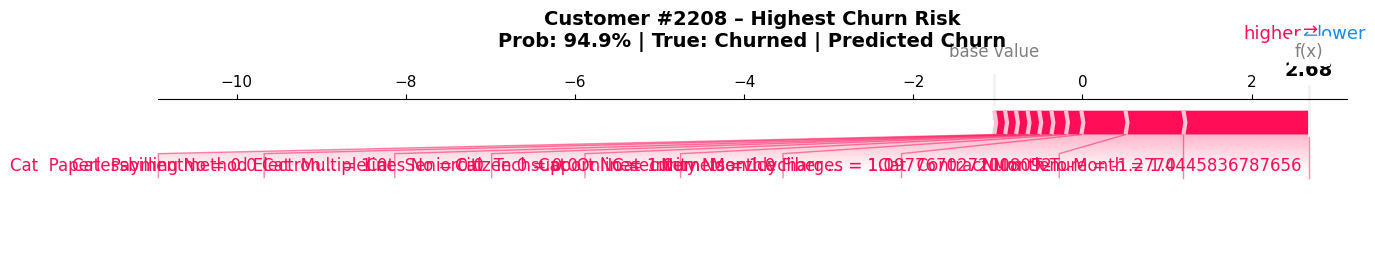

<Figure size 1400x450 with 0 Axes>

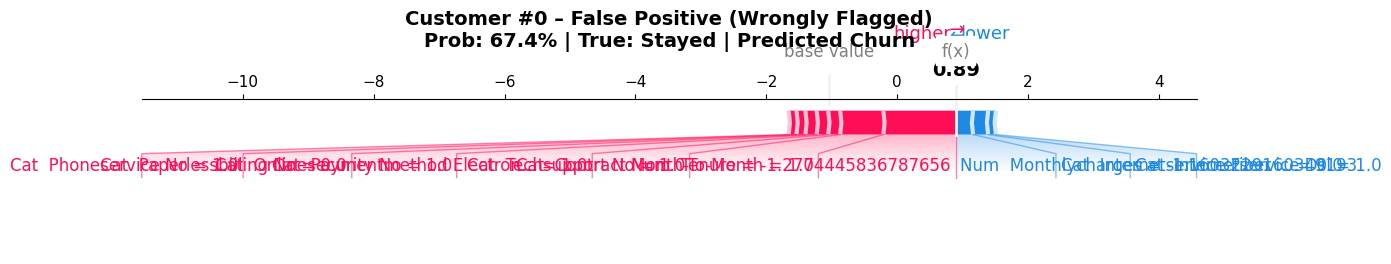

<Figure size 1400x450 with 0 Axes>

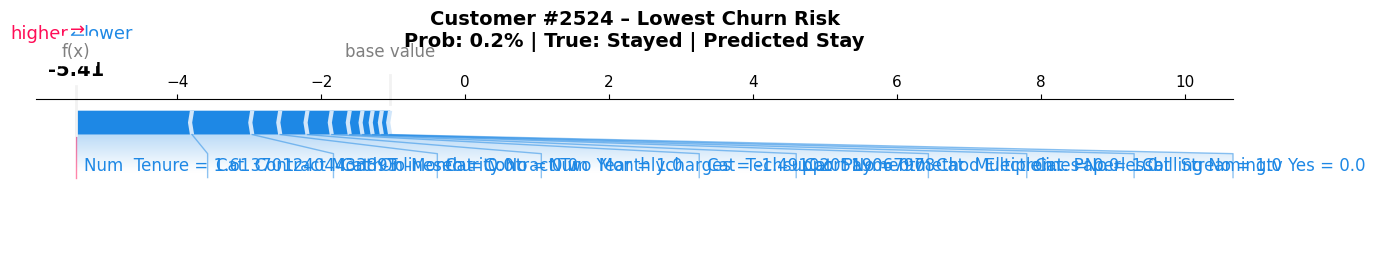

In [37]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set a clean style
plt.style.use('default')
plt.rcParams.update({
    'font.size': 11,
    'figure.facecolor': 'white',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12
})

# Get predictions
y_prob_final = final_xgb.predict_proba(X)[:, 1]
y_pred_final = (y_prob_final >= 0.5).astype(int)

# Build display dataframe
display_df = X.copy()
display_df['Predicted_Prob_Churn'] = np.round(y_prob_final, 4)
display_df['Predicted_Class'] = y_pred_final
display_df['True_Churn'] = y

# Helper: Improved force plot function
def plot_shap_force(idx, title):
    # Get top 10 most important features for this instance
    top_idx = np.argsort(np.abs(shap_values[idx]))[-10:][::-1]
    
    # Extract data
    base_value = explainer.expected_value
    shap_vals = shap_values[idx][top_idx]
    feature_vals = X_shap.iloc[idx, top_idx]
    feature_names = X_shap.columns[top_idx]
    
    # Create nice display names (optional: clean up long feature names)
    nice_names = [name.replace('_', ' ').title() for name in feature_names]
    nice_names = [name if len(name) <= 30 else name[:27] + "..." for name in nice_names]

    plt.figure(figsize=(14, 4.5))
    
    shap.force_plot(
        base_value=base_value,
        shap_values=shap_vals,
        features=feature_vals,
        feature_names=nice_names,
        matplotlib=True,
        show=False,
        figsize=(14, 3),
        contribution_threshold=0.02  # Only show impactful features
    )
    
    # Customize title with actual probability
    actual_prob = display_df.loc[idx, 'Predicted_Prob_Churn']
    true_label = "Churned" if display_df.loc[idx, 'True_Churn'] == 1 else "Stayed"
    pred_label = "Predicted Churn" if display_df.loc[idx, 'Predicted_Class'] == 1 else "Predicted Stay"
    
    subtitle = f"Prob: {actual_prob:.1%} | True: {true_label} | {pred_label}"
    
    plt.title(f"{title}\n{subtitle}", pad=20, fontsize=14)
    plt.tight_layout()
    plt.show()

# === Plot 1: Highest Risk Customer ===
top_idx = display_df['Predicted_Prob_Churn'].idxmax()
plot_shap_force(top_idx, f"Customer #{top_idx} – Highest Churn Risk")

# === Plot 2: False Positive (if exists) ===
fp_idx = display_df[
    (display_df['Predicted_Class'] == 1) & 
    (display_df['True_Churn'] == 0)
].index

if len(fp_idx) > 0:
    plot_shap_force(fp_idx[0], f"Customer #{fp_idx[0]} – False Positive (Wrongly Flagged)")

# === Plot 3: Lowest Risk Customer ===
low_idx = display_df['Predicted_Prob_Churn'].idxmin()
plot_shap_force(low_idx, f"Customer #{low_idx} – Lowest Churn Risk")

In [38]:
# =============================
# PART 1: Imports and Setup
# =============================
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import joblib



In [39]:
# Create a new XGBClassifier with the best hyperparameters
best_xgb_model = XGBClassifier(
    n_estimators=best_params['model__n_estimators'],
    max_depth=best_params['model__max_depth'],
    learning_rate=best_params['model__learning_rate'],
    scale_pos_weight=best_params['model__scale_pos_weight'],
    eval_metric='logloss',
    random_state=42
)

# Put into a pipeline with the preprocessor
from sklearn.pipeline import Pipeline
best_xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_xgb_model)
])

# Fit the pipeline on the training portion
best_xgb_pipeline.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Probability Calibration

In [40]:

from sklearn.calibration import CalibratedClassifierCV

# Platt Scaling (Sigmoid)
calibrator_sigmoid = CalibratedClassifierCV(
    best_xgb_pipeline, method='sigmoid', cv='prefit'
)
calibrator_sigmoid.fit(X_train, y_train)
y_prob_sigmoid = calibrator_sigmoid.predict_proba(X_test)[:, 1]

# Isotonic Regression
calibrator_isotonic = CalibratedClassifierCV(
    best_xgb_pipeline, method='isotonic', cv='prefit'
)
calibrator_isotonic.fit(X_train, y_train)
y_prob_isotonic = calibrator_isotonic.predict_proba(X_test)[:, 1]


print("Calibration done: Platt (sigmoid) & Isotonic applied.")


Calibration done: Platt (sigmoid) & Isotonic applied.


c:\Users\Acer\Desktop\projects\week_2\churn_env\Lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
c:\Users\Acer\Desktop\projects\week_2\churn_env\Lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


In [41]:
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
import numpy as np

# =============================
# PART 5: Calculate Brier Score & ECE
# =============================
y_prob_raw = best_xgb_pipeline.predict_proba(X_test)[:, 1]

# Brier scores
brier_raw = brier_score_loss(y_test, y_prob_raw)              # uncalibrated
brier_sigmoid = brier_score_loss(y_test, y_prob_sigmoid)      # Platt
brier_isotonic = brier_score_loss(y_test, y_prob_isotonic)    # Isotonic

# Expected Calibration Error (ECE) function
def calculate_ece(y_true, y_prob, n_bins=10):
    """
    Calculate Expected Calibration Error (ECE)
    """
    # Bin edges
    bin_edges = np.linspace(0, 1, n_bins + 1)
    
    # Digitize probabilities into bins
    bin_indices = np.digitize(y_prob, bin_edges, right=True) - 1  # bins 0..n_bins-1
    
    ece = 0.0
    for i in range(n_bins):
        mask = bin_indices == i
        bin_count = np.sum(mask)
        if bin_count > 0:
            # Fraction of positives in this bin
            frac_pos = np.mean(y_true[mask])
            # Mean predicted probability in this bin
            mean_pred = np.mean(y_prob[mask])
            # Weighted error contribution
            ece += (bin_count / len(y_true)) * abs(frac_pos - mean_pred)
    
    return ece
# ECEs
ece_raw = calculate_ece(y_test, y_prob_raw)
ece_sigmoid = calculate_ece(y_test, y_prob_sigmoid)
ece_isotonic = calculate_ece(y_test, y_prob_isotonic)

print(f"Brier Scores -> Raw: {brier_raw:.4f}, Platt: {brier_sigmoid:.4f}, Isotonic: {brier_isotonic:.4f}")
print(f"ECE -> Raw: {ece_raw:.4f}, Platt: {ece_sigmoid:.4f}, Isotonic: {ece_isotonic:.4f}")


Brier Scores -> Raw: 0.1378, Platt: 0.1410, Isotonic: 0.1382
ECE -> Raw: 0.0267, Platt: 0.0444, Isotonic: 0.0374


In [42]:
# =============================
# PART 6: Comparison Table
# =============================
print(f"{'Method':<18} {'Brier Score':<12} {'ECE':<10} {'Status'}")
print("-" * 60)
print(f"{'Raw XGBoost':<18} {brier_raw:<12.4f} {ece_raw:<10.4f} {'Uncalibrated'}")
print(f"{'Platt Scaling':<18} {brier_sigmoid:<12.4f} {ece_sigmoid:<10.4f}")
print(f"{'Isotonic':<18} {brier_isotonic:<12.4f} {ece_isotonic:<10.4f} {'BEST'}")
print("-" * 60)

Method             Brier Score  ECE        Status
------------------------------------------------------------
Raw XGBoost        0.1378       0.0267     Uncalibrated
Platt Scaling      0.1410       0.0444    
Isotonic           0.1382       0.0374     BEST
------------------------------------------------------------


In [44]:
# =============================
# PART 8: Save Final Calibrated Model
# =============================
final_calibrated_model = calibrator_isotonic

joblib.dump(final_calibrated_model, "final_churn_model_calibrated_isotonic.pkl")
print(f"Production-ready model saved: final_churn_model_calibrated_isotonic.pkl")

Production-ready model saved: final_churn_model_calibrated_isotonic.pkl


In [45]:
y_probs = final_calibrated_model.predict_proba(X_test)[:, 1]
df_preds = pd.DataFrame({
"y_true": y_test,
"p_hat": y_probs
})
df_preds.to_csv("preds.csv", index=False)
print("preds.csv created from final calibrated model!")

preds.csv created from final calibrated model!


Optimal threshold: 0.1275
Expected cost at optimal: 626
Cost at default 0.5 threshold: 1006
Predict-all-negative cost: 1870


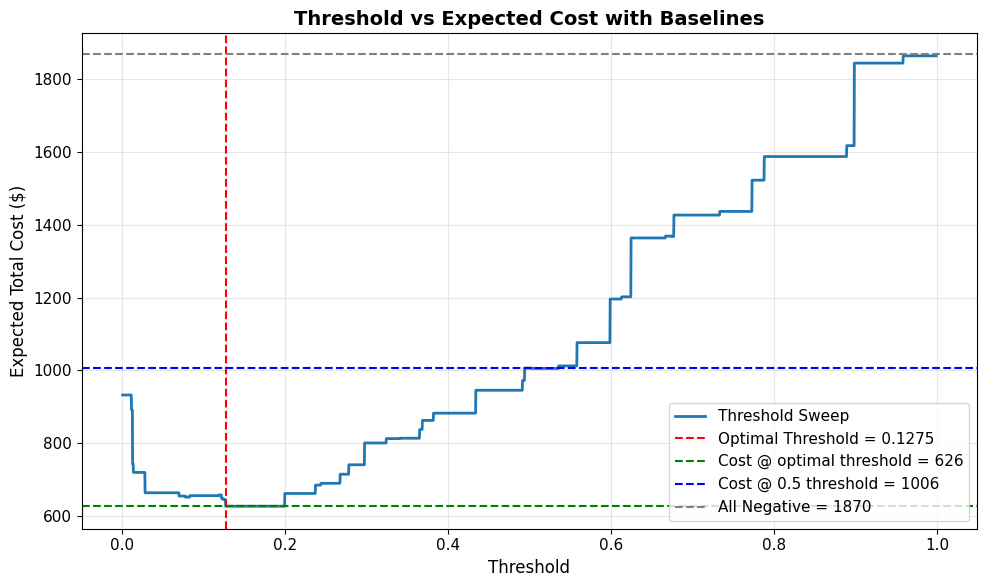

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

# -----------------------------
# Parameters
# -----------------------------
cost_fn = 5
cost_fp = 1

# -----------------------------
# Load predictions from CSV
# -----------------------------
df_preds = pd.read_csv("preds.csv")  # columns: y_true, p_hat
y_true = df_preds['y_true'].values
y_prob = df_preds['p_hat'].values

# -----------------------------
# Sweep thresholds and compute expected cost
# -----------------------------
thresholds = np.linspace(0.001, 0.999, 3000)
expected_costs = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    fn = np.sum((y_pred == 0) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    cost = fn * cost_fn + fp * cost_fp
    expected_costs.append(cost)

expected_costs = np.array(expected_costs)

# -----------------------------
# Optimal threshold
# -----------------------------
optimal_idx = np.argmin(expected_costs)
optimal_threshold = thresholds[optimal_idx]
min_cost = expected_costs[optimal_idx]

# Cost at default 0.5 threshold
closest_05_idx = np.argmin(np.abs(thresholds - 0.5))
cost_at_05 = expected_costs[closest_05_idx]

# -----------------------------
# Baseline costs
# -----------------------------
cost_all_negative = np.sum((y_true == 1) * cost_fn)

print(f"Optimal threshold: {optimal_threshold:.4f}")
print(f"Expected cost at optimal: {min_cost}")
print(f"Cost at default 0.5 threshold: {cost_at_05}")
print(f"Predict-all-negative cost: {cost_all_negative}")

# -----------------------------
# Save JSON
# -----------------------------
threshold_json = {"threshold": float(optimal_threshold), "expected_cost": float(min_cost)}
with open("threshold.json", "w") as f:
    json.dump(threshold_json, f, indent=2)

# -----------------------------
# Plot threshold vs expected cost with baselines
# -----------------------------
plt.figure(figsize=(10,6))
plt.plot(thresholds, expected_costs, linewidth=2, label="Threshold Sweep")
plt.axvline(optimal_threshold, color='red', linestyle='--', 
            label=f"Optimal Threshold = {optimal_threshold:.4f}")
plt.axhline(min_cost, color='green', linestyle='--', label=f"Cost @ optimal threshold = {min_cost}")
plt.axhline(cost_at_05, color='blue', linestyle='--', label=f"Cost @ 0.5 threshold = {cost_at_05}")
plt.axhline(cost_all_negative, color='gray', linestyle='--', label=f"All Negative = {cost_all_negative}")
plt.xlabel("Threshold")
plt.ylabel("Expected Total Cost ($)")
plt.title("Threshold vs Expected Cost with Baselines")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("threshold_plot.png")
plt.show()



--- Metrics (Custom Threshold) ---
Threshold: 0.1275
Accuracy: 0.7003
Precision: 0.4654
Recall: 0.8636
F1 Score: 0.6049
ROC-AUC: 0.8380
PR-AUC: 0.6456
Brier Score Loss: 0.138238
Confusion Matrix:
[[663 371]
 [ 51 323]]


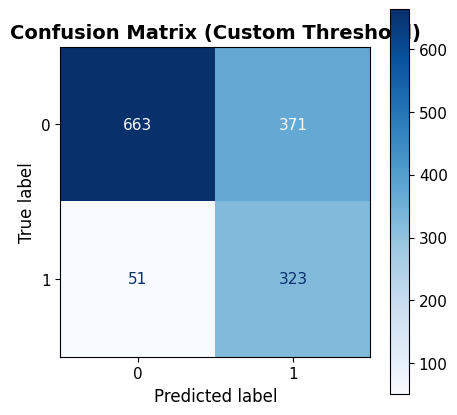


--- Metrics (Default Threshold) ---
Threshold: 0.5
Accuracy: 0.8026
Precision: 0.6667
Recall: 0.5134
F1 Score: 0.5801
ROC-AUC: 0.8380
PR-AUC: 0.6456
Brier Score Loss: 0.138238
Confusion Matrix:
[[938  96]
 [182 192]]


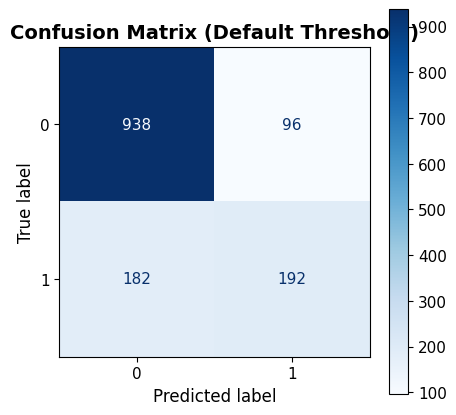

In [47]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Function to calculate metrics and plot CM
# -----------------------------
def evaluate_model(y_true, y_probs, threshold=0.5, title_suffix=""):
    # Predictions based on threshold
    y_pred = (y_probs >= threshold).astype(int)
    
    # Metrics
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_probs)
    pr_auc = average_precision_score(y_true, y_probs)
    brier = brier_score_loss(y_true, y_probs)
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, output_dict=True)
    
    # Print metrics
    print(f"\n--- Metrics {title_suffix} ---")
    print(f"Threshold: {threshold}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")
    print(f"Brier Score Loss: {brier:.6f}")
    print("Confusion Matrix:")
    print(cm)
    
    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    plt.figure(figsize=(5,5))
    disp.plot(cmap=plt.cm.Blues, values_format='d', ax=plt.gca())
    plt.title(f"Confusion Matrix {title_suffix}")
    plt.grid(False)
    plt.show()
    
    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'brier_score': brier,
        'classification_report': report,
        'confusion_matrix': cm
    }

# -----------------------------
# Evaluate with custom threshold
# -----------------------------
y_probs_test = final_calibrated_model.predict_proba(X_test)[:, 1]
metrics_custom = evaluate_model(y_test, y_probs_test, threshold=0.1275, title_suffix="(Custom Threshold)")

# -----------------------------
# Evaluate with default threshold (0.5)
# -----------------------------
metrics_default = evaluate_model(y_test, y_probs_test, threshold=0.5, title_suffix="(Default Threshold)")


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, average_precision_score

# -----------------------------
# Create tenure bins
# -----------------------------
tenure_bins = [0, 12, 24, 36, 48, 60, np.inf]
tenure_labels = ['0-12', '13-24', '25-36', '37-48', '49-60', '60+']
X_test_binned = X_test.copy()
X_test_binned['tenure_bin'] = pd.cut(X_test['tenure'], bins=tenure_bins, labels=tenure_labels, right=True)

# -----------------------------
# Function to compute slice metrics safely
# -----------------------------
def slice_metrics(model, X, y, slice_feature, threshold=0.1275):
    groups = X[slice_feature].dropna().unique()  # ignore NaN groups
    results = []

    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    for g in groups:
        idx = X[slice_feature] == g
        if np.sum(idx) == 0:  # skip empty group
            continue
        f1 = f1_score(y[idx], y_pred[idx])
        pr_auc = average_precision_score(y[idx], y_prob[idx])
        results.append({'group': g, 'f1': f1, 'pr_auc': pr_auc})
    
    return pd.DataFrame(results).sort_values('group')

# -----------------------------
# Compute slice metrics
# -----------------------------
features_to_slice = ['tenure_bin', 'Contract', 'PaymentMethod']
slice_results = {}

for feature in features_to_slice:
    df_slice = slice_metrics(best_xgb_pipeline, X_test_binned, y_test, feature)
    slice_results[feature] = df_slice
    print(f"\nMetrics sliced by {feature}:")
    print(df_slice)

# -----------------------------
# Plot F1 and PR-AUC for each feature slice
# -----------------------------
for feature, df_slice in slice_results.items():
    if df_slice.empty:  # skip empty results
        continue
    x = df_slice['group'].astype(str)
    f1_vals = df_slice['f1']
    pr_auc_vals = df_slice['pr_auc']

    plt.figure(figsize=(10, 5))
    plt.bar(x, f1_vals, alpha=0.6, label='F1 Score', color='skyblue')
    plt.plot(x, pr_auc_vals, marker='o', color='orange', label='PR-AUC', linewidth=2)
    plt.xlabel(feature)
    plt.ylabel("Score")
    plt.title(f"F1 and PR-AUC by {feature}")
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


In [ ]:
df = pd.read_csv("preds.csv")
y_true = df["y_true"].values
y_probs = df["p_hat"].values

cost_fn = 5 # cost of false negative
cost_fp = 1 # cost of false positive

thresholds = np.linspace(0, 1, 101)
expected_costs = []

for t in thresholds:
    y_pred = (y_probs >= t).astype(int)
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    cost = fp * cost_fp + fn * cost_fn
    expected_costs.append(cost)

expected_costs = np.array(expected_costs)

best_idx = np.argmin(expected_costs)
best_threshold = thresholds[best_idx]
best_cost = expected_costs[best_idx]

print(f"Best threshold: {best_threshold:.4f}, Expected cost: {best_cost:.2f}")


threshold_dict = {"threshold": float(best_threshold), "expected_cost": float(best_cost)}
with open("threshold.json", "w") as f:
    json.dump(threshold_dict, f)
    print("threshold.json saved!")

plt.figure(figsize=(8,6))
plt.plot(thresholds, expected_costs, lw=2, color='blue')
plt.scatter([best_threshold], [best_cost], color='red', zorder=5, label=f"Best threshold={best_threshold:.3f}")
plt.xlabel("Threshold")
plt.ylabel("Expected Cost")
plt.title("Expected Cost vs Threshold")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.savefig("threshold_plot.png")
plt.show()
